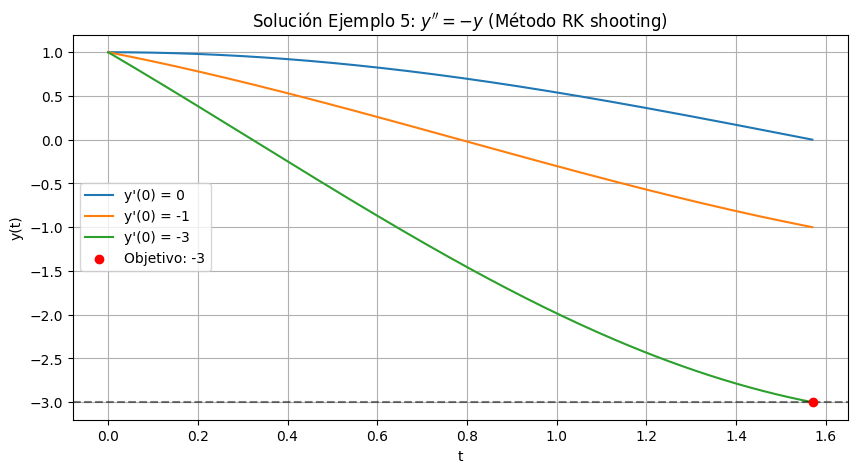

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

t_sym = sp.symbols('t')
y_sym = sp.Function('y')('t')

eq = sp.Eq(y_sym.diff(t_sym, t_sym), -y_sym)

v_sym = sp.symbols('v')
f_num = sp.lambdify((y_sym, v_sym), [v_sym, -y_sym], 'numpy')


t_inicio, t_fin = 0, np.pi/2
y_inicio = 1
y_objetivo = -3
h = 0.01
pasos = int((t_fin - t_inicio) / h)


def rk4_step(f, t, y, v, h):
    k1y, k1v = f(y, v)
    k2y, k2v = f(y + 0.5*h*k1y, v + 0.5*h*k1v)
    k3y, k3v = f(y + 0.5*h*k2y, v + 0.5*h*k2v)
    k4y, k4v = f(y + h*k3y, v + h*k3v)

    y_next = y + (h/6.0)*(k1y + 2*k2y + 2*k3y + k4y)
    v_next = v + (h/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
    return y_next, v_next


pendientes_a_probar = [0, -1, -3]
plt.figure(figsize=(10, 5))

for v0 in pendientes_a_probar:
    t_vals = [t_inicio]
    y_vals = [y_inicio]
    v_actual = v0
    y_actual = y_inicio

    for _ in range(pasos):
        y_actual, v_actual = rk4_step(f_num, t_vals[-1], y_actual, v_actual, h)
        t_vals.append(t_vals[-1] + h)
        y_vals.append(y_actual)

    plt.plot(t_vals, y_vals, label=f"y'(0) = {v0}")

plt.axhline(y=y_objetivo, color='black', linestyle='--', alpha=0.5)
plt.scatter([t_fin], [y_objetivo], color='red', zorder=5, label=f"Objetivo: {y_objetivo}")
plt.title("Solución Ejemplo 5: $y'' = -y$ (Método RK shooting)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()